In [35]:
# IMPOR PUSTAKA, KONFIGURASI, DAN REPRODUKSIBILITAS

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from torch.utils.data import Dataset
from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

# Konfigurasi Utama
SEED = 42
MODEL_NAME = "indobenchmark/indobert-base-p2"
MAX_LENGTH = 160
THRESHOLD = 0.50

# Path Data dan Output
TRAIN_PATH = Path("train_data_encoded.csv")
VAL_PATH = Path("val_data_encoded.csv")
TEST_PATH = Path("test_data_encoded.csv")
OUTPUT_DIR = Path("./hasil_indobert_pos_weight")
FINAL_MODEL_DIR = Path("./model_indobert_redbus_best")

# Definisi Kolom
TEXT_COLUMN = "review_backtranslated"
LABEL_COLUMNS = [
    "Ticketing_Positif",
    "Ticketing_Negatif",
    "Information Channels_Positif",
    "Information Channels_Negatif",
    "Travel Experience_Positif",
    "Travel Experience_Negatif",
]

# Reproduksibilitas
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Perangkat yang digunakan: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}\n")

Perangkat yang digunakan: cuda
GPU: NVIDIA GeForce GTX 1650



In [36]:
# MEMUAT DAN MEMVALIDASI DATA

train_df = pd.read_csv(TRAIN_PATH, encoding="utf-8-sig")
val_df = pd.read_csv(VAL_PATH, encoding="utf-8-sig")
test_df = pd.read_csv(TEST_PATH, encoding="utf-8-sig")

required_columns = [TEXT_COLUMN] + LABEL_COLUMNS
datasets = {"train": train_df, "validation": val_df, "test": test_df}

for subset_name, dataframe in datasets.items():
    dataframe.columns = dataframe.columns.str.strip()
    missing_columns = [col for col in required_columns if col not in dataframe.columns]
    
    if missing_columns:
        raise ValueError(f"Kolom pada data {subset_name} tidak lengkap: {missing_columns}")

    dataframe[TEXT_COLUMN] = dataframe[TEXT_COLUMN].fillna("").astype(str).str.strip()
    dataframe[LABEL_COLUMNS] = dataframe[LABEL_COLUMNS].fillna(0).astype(np.float32)

    if dataframe[TEXT_COLUMN].eq("").any():
        raise ValueError(f"Data {subset_name} masih mengandung teks kosong.")

    invalid_labels = ~dataframe[LABEL_COLUMNS].isin([0, 1])
    if invalid_labels.any().any():
        raise ValueError(f"Data {subset_name} mengandung label selain 0 dan 1.")

print(f"Jumlah data train      : {len(train_df)}")
print(f"Jumlah data validation : {len(val_df)}")
print(f"Jumlah data test       : {len(test_df)}\n")

Jumlah data train      : 1573
Jumlah data validation : 201
Jumlah data test       : 203



In [37]:
# TOKENIZER DAN DATASET PYTORCH

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class RedbusDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe[TEXT_COLUMN].tolist()
        self.labels = dataframe[LABEL_COLUMNS].to_numpy(dtype=np.float32)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        encoding = tokenizer(
            self.texts[index],
            max_length=MAX_LENGTH,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[index], dtype=torch.float32),
        }

train_dataset = RedbusDataset(train_df)
val_dataset = RedbusDataset(val_df)
test_dataset = RedbusDataset(test_df)

In [51]:
train_dataset = RedbusDataset(train_df)

# Mengambil baris pertama dari dataset (indeks 0)
sample = train_dataset[11]

# Mengekstrak list ID untuk dikembalikan menjadi teks/token
token_ids = sample["input_ids"].tolist()
tokens = tokenizer.convert_ids_to_tokens(token_ids)
decoded_text = tokenizer.decode(token_ids)

# ==========================================
# 4. MENAMPILKAN OUTPUT TENSOR & TOKEN
# ==========================================
print("--- TENSOR OUTPUT (Representasi Mesin) ---")
print(f"Input IDs      :\n{sample['input_ids']}\n")
print(f"Attention Mask :\n{sample['attention_mask']}\n")
print(f"Labels         : {sample['labels']}\n")

print("--- HASIL TOKENISASI (Representasi Manusia) ---")
print(f"Daftar Tokens  :\n{tokens}\n")
print(f"Teks Decoded   :\n{decoded_text}")

--- TENSOR OUTPUT (Representasi Mesin) ---
Input IDs      :
tensor([   2,  699, 3927, 1761,  783,    3,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0

In [39]:
# INISIALISASI MODEL INDOBERT (FULL FINE-TUNING)

config = AutoConfig.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_COLUMNS),
    problem_type="multi_label_classification",
    hidden_dropout_prob=0.20,
    attention_probs_dropout_prob=0.20,
    id2label={idx: label for idx, label in enumerate(LABEL_COLUMNS)},
    label2id={label: idx for idx, label in enumerate(LABEL_COLUMNS)},
)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, config=config)

# Mengaktifkan seluruh parameter untuk proses training
for parameter in model.parameters():
    parameter.requires_grad = True

model.to(device)

total_parameters = sum(p.numel() for p in model.parameters())
trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameter   : {total_parameters:,}")
print(f"Parameter dilatih : {trainable_parameters:,}")
print("Strategi          : Full fine-tuning\n")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameter   : 124,445,958
Parameter dilatih : 124,445,958
Strategi          : Full fine-tuning



In [40]:
# PERHITUNGAN POS WEIGHT & CUSTOM TRAINER

train_labels = train_df[LABEL_COLUMNS].to_numpy(dtype=np.float32)
positive_counts = train_labels.sum(axis=0)
negative_counts = len(train_labels) - positive_counts

# Mencegah pembagian nol
safe_positive_counts = np.where(positive_counts == 0, 1, positive_counts)
pos_weights = negative_counts / safe_positive_counts
pos_weight_tensor = torch.tensor(pos_weights, dtype=torch.float32)

class WeightedTrainer(Trainer):
    def __init__(self, *args, pos_weight=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.pos_weight = pos_weight

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs["labels"]
        model_inputs = {key: val for key, val in inputs.items() if key != "labels"}
        outputs = model(**model_inputs)
        logits = outputs.logits

        loss_function = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight.to(logits.device))
        loss = loss_function(logits, labels.to(logits.device))

        return (loss, outputs) if return_outputs else loss

In [41]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Pastikan Anda telah mendefinisikan THRESHOLD secara global (misal: THRESHOLD = 0.5)

def sigmoid(logits):
    """Menghitung probabilitas dari nilai mentah (logits)."""
    logits = np.clip(logits, -50, 50)
    return 1.0 / (1.0 + np.exp(-logits))

def compute_metrics(eval_prediction):
    """Fungsi utama untuk komputasi metrik evaluasi model."""
    logits, true_labels = eval_prediction
    
    # Menangani kasus di mana model mengembalikan tuple
    if isinstance(logits, tuple):
        logits = logits[0]

    # Konversi logits menjadi probabilitas (0 sampai 1)
    probabilities = sigmoid(logits)
    
    # Konversi probabilitas menjadi prediksi biner berdasarkan batas ambang
    predictions = (probabilities >= THRESHOLD).astype(np.int8)
    true_labels = true_labels.astype(np.int8)


    accuracy = accuracy_score(true_labels, predictions)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        true_labels, predictions, average="macro", zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
    }

In [42]:
# PROSES PELATIHAN (TRAINING)

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.10,
    max_grad_norm=1.0,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=1,
    seed=SEED,
    data_seed=SEED,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    pos_weight=pos_weight_tensor,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=3,
            early_stopping_threshold=0.001,
        )
    ],
)

print("Memulai proses training...")
trainer.train()

print("\nTraining selesai.")
print(f"Checkpoint terbaik: {trainer.state.best_model_checkpoint}")
print(f"Validation macro F1 terbaik: {trainer.state.best_metric:.4f}\n")

Memulai proses training...


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.947600,0.571760,0.213930,0.531328,0.937273,0.672152
2,0.486900,0.381060,0.567164,0.662713,0.934413,0.765862
3,0.333600,0.398791,0.696517,0.771404,0.868150,0.808570
4,0.235300,0.332598,0.696517,0.770709,0.910179,0.831891
5,0.173600,0.345707,0.696517,0.748846,0.878779,0.803861
6,0.130500,0.353959,0.731343,0.809304,0.885940,0.840067
7,0.105300,0.392857,0.721393,0.812760,0.860574,0.833155
8,0.089800,0.444263,0.726368,0.824538,0.857702,0.835064
9,0.076100,0.406110,0.706468,0.809450,0.858816,0.828881



Training selesai.
Checkpoint terbaik: hasil_indobert_pos_weight\checkpoint-594
Validation macro F1 terbaik: 0.8401



In [43]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

test_output = trainer.predict(test_dataset)
test_logits = test_output.predictions[0] if isinstance(test_output.predictions, tuple) else test_output.predictions
test_true = test_output.label_ids.astype(np.int8)

# Mengkonversi logits ke probabilitas dan memotong dengan threshold
test_predictions = (sigmoid(test_logits) >= THRESHOLD).astype(np.int8)

# A. Subset Accuracy (Sangat Ketat: Himpunan prediksi harus 100% identik dengan aktual)
subset_acc = accuracy_score(test_true, test_predictions)

# B. Makro Presisi, Recall, dan F1-Score
macro_p, macro_r, macro_f1_test, _ = precision_recall_fscore_support(
    test_true, test_predictions, average="macro", zero_division=0
)

# Integrasi ke dalam DataFrame
overall_metrics = pd.DataFrame({
    "Metrik": ["Subset Accuracy", "Macro Precision", "Macro Recall", "Macro F1-score"],
    "Nilai": [subset_acc, macro_p, macro_r, macro_f1_test],
})
overall_metrics["Persentase (%)"] = (overall_metrics["Nilai"] * 100).round(2)

label_p, label_r, label_f1_scores, label_supp = precision_recall_fscore_support(
    test_true, test_predictions, average=None, zero_division=0
)

# Fungsi accuracy_score di sini dipertahankan khusus untuk evaluasi biner per label
label_acc = [accuracy_score(test_true[:, i], test_predictions[:, i]) for i in range(len(LABEL_COLUMNS))]

per_label_metrics = pd.DataFrame({
    "Label": LABEL_COLUMNS,
    "Accuracy": label_acc,
    "Precision": label_p,
    "Recall": label_r,
    "F1-score": label_f1_scores,
    "Support": label_supp.astype(int),
})

# Membuat baris Macro Average untuk diletakkan di bagian terbawah tabel
macro_average_df = pd.DataFrame({
    "Label": ["Macro Average"],
    "Accuracy": [np.mean(label_acc)], # Representasi empiris dari Hamming Accuracy
    "Precision": [np.mean(label_p)],
    "Recall": [np.mean(label_r)],
    "F1-score": [np.mean(label_f1_scores)],
    "Support": [int(np.sum(label_supp))],
})

# Menggabungkan DataFrame label individual dengan baris Macro Average
per_label_metrics = pd.concat([per_label_metrics, macro_average_df], ignore_index=True).round(4)

print("Evaluasi Kinerja Model Final pada Data Test (Hold-out):")
display(overall_metrics)
print("\nDekonstruksi Kinerja Model Berdasarkan Kelas Label:")
display(per_label_metrics)

Evaluasi Kinerja Model Final pada Data Test (Hold-out):


,Metrik,Nilai,Persentase (%)
0,Subset Accuracy,0.729064,72.91
1,Macro Precision,0.810897,81.09
2,Macro Recall,0.877970,87.80
3,Macro F1-score,0.839863,83.99



Dekonstruksi Kinerja Model Berdasarkan Kelas Label:


,Label,Accuracy,Precision,Recall,F1-score,Support
0,Ticketing_Positif,0.9557,0.8600,0.9556,0.9053,45
1,Ticketing_Negatif,0.9409,0.7692,0.9091,0.8333,33
2,Information Channels_Positif,0.9507,0.8889,0.8889,0.8889,45
3,Information Channels_Negatif,0.8719,0.7952,0.8800,0.8354,75
4,Travel Experience_Positif,0.9852,0.8333,0.7143,0.7692,7
5,Travel Experience_Negatif,0.9458,0.7188,0.9200,0.8070,25
6,Macro Average,0.9417,0.8109,0.8780,0.8399,230


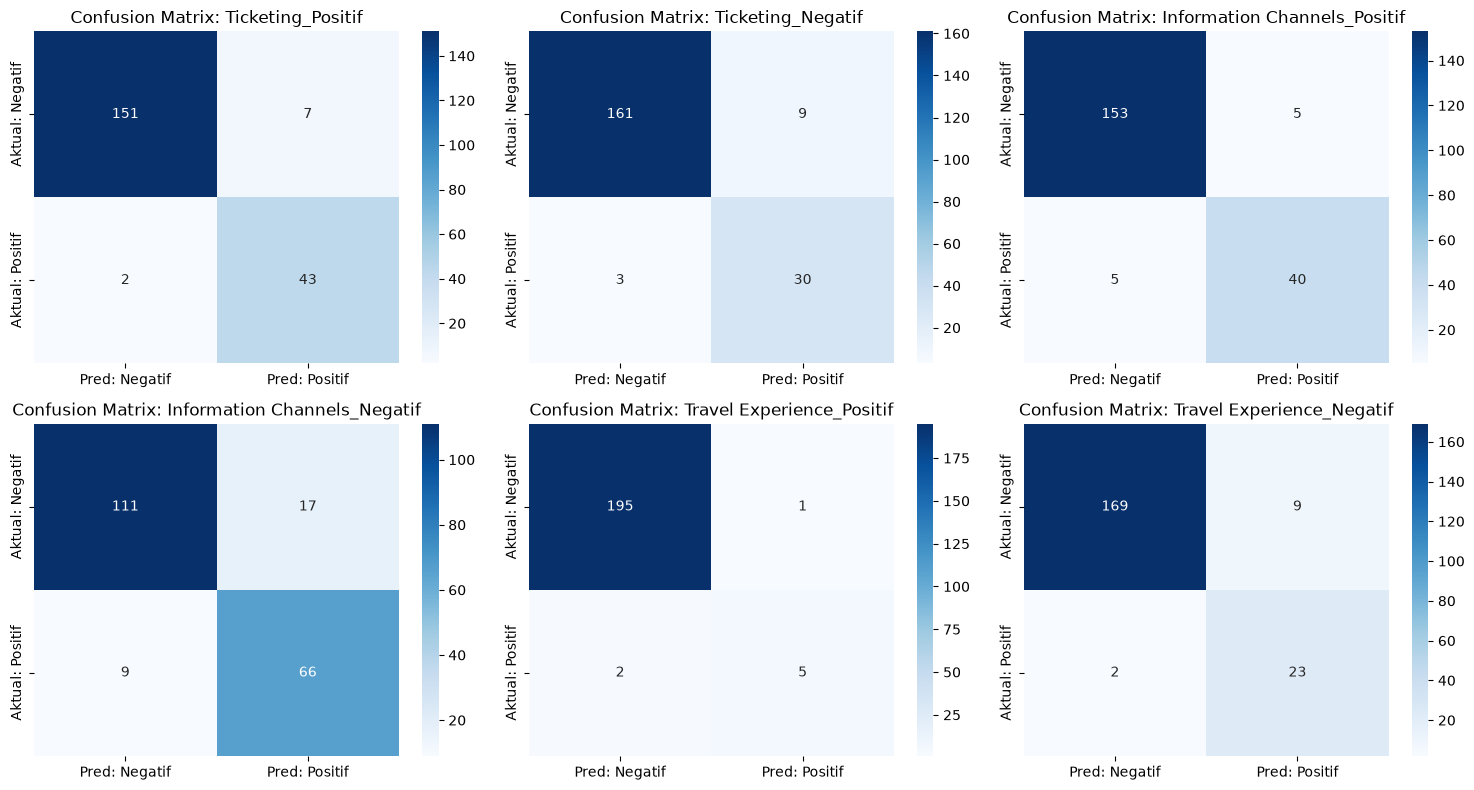

In [44]:
from sklearn.metrics import multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Menghitung matriks konfusi untuk seluruh label
mcm = multilabel_confusion_matrix(test_true, test_predictions)

# 2. Setup grid untuk visualisasi (menyesuaikan jumlah label)
num_labels = len(LABEL_COLUMNS)
cols = 3 # Menampilkan 3 matriks per baris
rows = (num_labels + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()

# 3. Looping untuk menggambar heatmap per label
for i, (label_name, matrix) in enumerate(zip(LABEL_COLUMNS, mcm)):
    ax = axes[i]
    # Menggunakan seaborn untuk estetika visual yang rapi
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: Negatif', 'Pred: Positif'],
                yticklabels=['Aktual: Negatif', 'Aktual: Positif'])
    ax.set_title(f'Confusion Matrix: {label_name}')

# 4. Merapikan layout jika ada kotak subplot yang kosong
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [52]:
# PENYIMPANAN ARTEFAK MODEL DAN HASIL

trainer.save_model(str(FINAL_MODEL_DIR))
tokenizer.save_pretrained(str(FINAL_MODEL_DIR))

overall_metrics.to_csv("evaluasi_overall_best_model.csv", index=False, encoding="utf-8-sig")
per_label_metrics.to_csv("evaluasi_per_label_best_model.csv", index=False, encoding="utf-8-sig")

# Menyimpan tabel pos_weight
pos_weight_table = pd.DataFrame({
    "Label": LABEL_COLUMNS,
    "Positif_Train": positive_counts.astype(int),
    "Negatif_Train": negative_counts.astype(int),
    "Pos_Weight": np.round(pos_weights, 4),
})
pos_weight_table.to_csv("pos_weight_train.csv", index=False, encoding="utf-8-sig")

print(f"\nBest model berhasil disimpan di: {FINAL_MODEL_DIR}")
print("File metrik (overall, per label, pos_weight) telah disimpan dalam format CSV.")


Best model berhasil disimpan di: model_indobert_redbus_best
File metrik (overall, per label, pos_weight) telah disimpan dalam format CSV.
